In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("37-cardekho.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [9]:
df.drop(columns='Unnamed: 0', inplace=True)

In [10]:
categorical = [col for col in df.columns if df[col].dtype == 'O']
numerical = [col for col in df.columns if df[col].dtype != 'O']

In [11]:
categorical

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [12]:
numerical

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

In [18]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [19]:
df.duplicated().sum()

167

In [20]:
df.drop_duplicates(ignore_index=True, inplace=True)

In [21]:
df.duplicated().sum()

0

In [22]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326161,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.808760,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [23]:
df.seats.value_counts()

seats
5    12767
7     1902
8      310
6      125
4       76
9       55
2        7
0        2
Name: count, dtype: int64

In [25]:
df[df.seats==0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [26]:
df.loc[df['seats'] == 0, 'seats'] = 5

In [27]:
df[df.seats==0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [28]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [29]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00
mean,6.04,55639.58,19.70,1486.17,100.61,5.33,774701.45
std,3.02,51766.30,4.17,520.42,42.92,0.81,894676.08
min,0.00,100.00,4.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,559000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [30]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


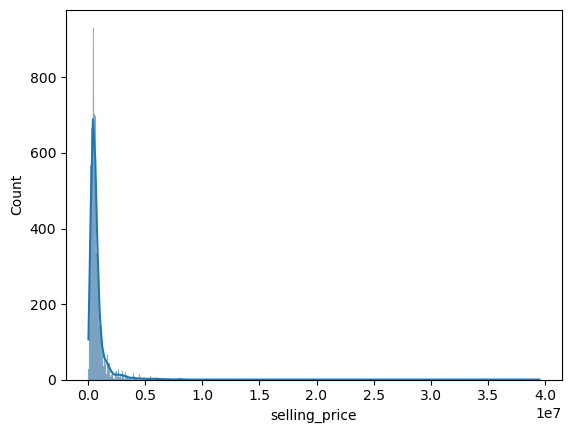

In [35]:
sns.histplot(df["selling_price"], kde=True)
plt.show()

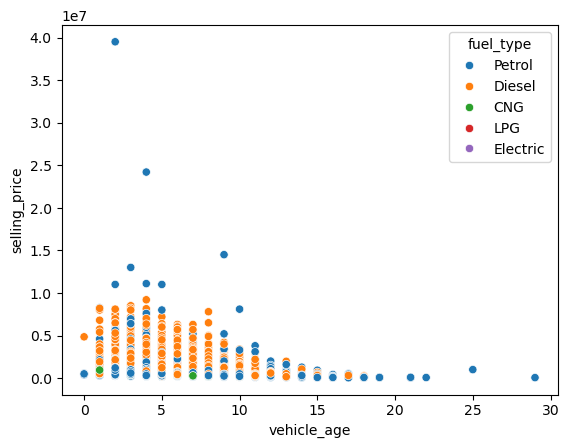

In [36]:
sns.scatterplot(x=df['vehicle_age'], y=df['selling_price'], hue=df['fuel_type'])
plt.show()

In [37]:
df.selling_price.max()

39500000

In [44]:
df = df[df.selling_price < 10000000]

In [46]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15237.00,15237.00,15237.00,15237.00,15237.00,15237.00,15237.00
mean,6.04,55658.27,19.70,1484.68,100.43,5.33,766899.58
std,3.02,51770.12,4.16,515.17,42.06,0.81,789564.21
min,0.00,100.00,6.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,557000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,5998.00,600.00,9.00,9200000.00


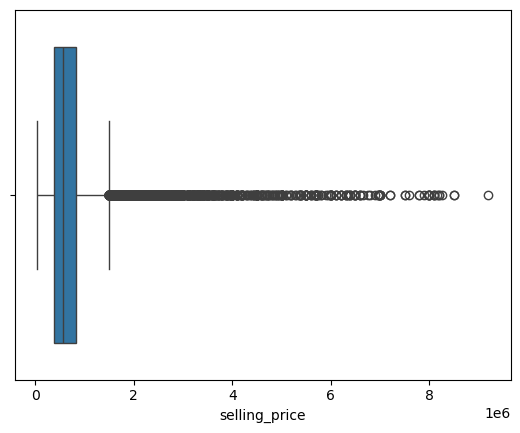

In [47]:
sns.boxplot(x=df["selling_price"])
plt.show()

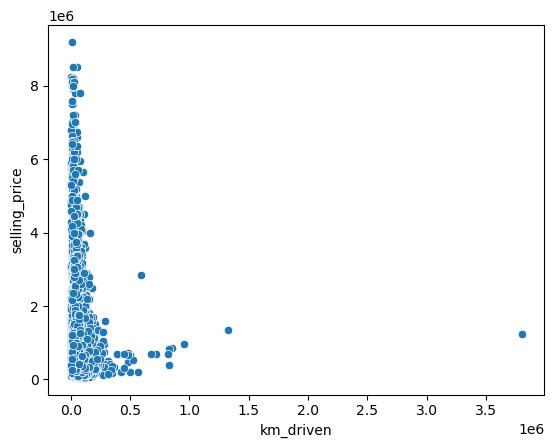

In [48]:
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.show()

In [49]:
df['km_driven'].max()

3800000

In [50]:
df = df[df.km_driven < 1000000]

In [51]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15235.00,15235.00,15235.00,15235.00,15235.00,15235.00,15235.00
mean,6.04,55329.18,19.70,1484.53,100.42,5.33,766831.24
std,3.02,40673.18,4.16,515.03,42.05,0.81,789593.18
min,0.00,100.00,6.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,557000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,823500.00
max,29.00,950000.00,33.54,5998.00,600.00,9.00,9200000.00


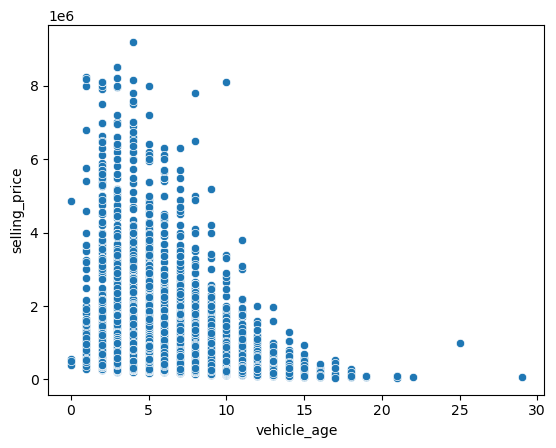

In [54]:
sns.scatterplot(x="vehicle_age", y="selling_price", data=df)
plt.show()

In [56]:
df.corr(numeric_only=True)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.00,0.42,-0.26,0.10,0.01,0.03,-0.27
km_driven,0.42,1.00,-0.13,0.24,0.05,0.23,-0.11
mileage,-0.26,-0.13,1.00,-0.63,-0.53,-0.44,-0.32
engine,0.10,0.24,-0.63,1.00,0.80,0.56,0.61
max_power,0.01,0.05,-0.53,0.80,1.00,0.18,0.77
seats,0.03,0.23,-0.44,0.56,0.18,1.00,0.14
selling_price,-0.27,-0.11,-0.32,0.61,0.77,0.14,1.00


# Encoding

In [58]:
for col in categorical:
    print(col)
    print(df[col].unique())
    print("-----------------------------------")

car_name
['Maruti Alto' 'Hyundai Grand' 'Hyundai i20' 'Ford Ecosport'
 'Maruti Wagon R' 'Hyundai i10' 'Hyundai Venue' 'Maruti Swift'
 'Hyundai Verna' 'Renault Duster' 'Mini Cooper' 'Maruti Ciaz'
 'Mercedes-Benz C-Class' 'Toyota Innova' 'Maruti Baleno'
 'Maruti Swift Dzire' 'Volkswagen Vento' 'Hyundai Creta' 'Honda City'
 'Mahindra Bolero' 'Toyota Fortuner' 'Renault KWID' 'Honda Amaze'
 'Hyundai Santro' 'Mahindra XUV500' 'Mahindra KUV100' 'Maruti Ignis'
 'Datsun RediGO' 'Mahindra Scorpio' 'Mahindra Marazzo' 'Ford Aspire'
 'Ford Figo' 'Maruti Vitara' 'Tata Tiago' 'Volkswagen Polo' 'Kia Seltos'
 'Maruti Celerio' 'Datsun GO' 'BMW 5' 'Honda CR-V' 'Ford Endeavour'
 'Mahindra KUV' 'Honda Jazz' 'BMW 3' 'Audi A4' 'Tata Tigor'
 'Maruti Ertiga' 'Tata Safari' 'Mahindra Thar' 'Tata Hexa'
 'Land Rover Rover' 'Maruti Eeco' 'Audi A6' 'Mercedes-Benz E-Class'
 'Audi Q7' 'BMW Z4' 'BMW 6' 'Jaguar XF' 'BMW X5' 'MG Hector' 'Honda Civic'
 'Isuzu D-Max' 'Porsche Cayenne' 'BMW X1' 'Skoda Rapid' 'Ford Freestyle

In [59]:
one_hot_columns = ["seller_type","fuel_type","transmission_type"]
target_columns = ["car_name","brand","model"]

In [60]:
X = df.drop('selling_price', axis=1)
y = df.selling_price

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

In [63]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
11447,Land Rover Rover,Land Rover,Rover,3,18000,Dealer,Diesel,Automatic,18.00,2993,255.00,7
12774,Mahindra XUV500,Mahindra,XUV500,6,50000,Individual,Diesel,Manual,15.10,2179,140.00,7
4018,Maruti Eeco,Maruti,Eeco,3,33000,Dealer,Petrol,Manual,16.11,1196,72.42,5
7637,Toyota Fortuner,Toyota,Fortuner,10,140782,Dealer,Diesel,Manual,11.50,2982,171.00,7
15193,Toyota Innova,Toyota,Innova,10,50000,Individual,Diesel,Manual,12.80,2494,102.00,7


In [64]:
car_mean_price = X_train.join(y_train).groupby("car_name")["selling_price"].mean().to_dict()

In [66]:
X_train["car_name_target"] = X_train["car_name"].map(car_mean_price)

In [67]:
X_test["car_name_target"] = X_test["car_name"].map(car_mean_price)

In [68]:
X_test["car_name_target"].fillna(X_train["car_name_target"].mean(), inplace=True)

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_16240\2205588299.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["car_name_target"].fillna(X_train["car_name_target"].mean(), inplace=True)


In [71]:
X_train = X_train.drop('car_name', axis=1)
X_test = X_test.drop('car_name', axis=1)

In [74]:
car_mean_price = X_train.join(y_train).groupby("brand")["selling_price"].mean().to_dict()
X_train["brand_target"] = X_train["brand"].map(car_mean_price)
X_test["brand_target"] = X_test["brand"].map(car_mean_price)
X_test["brand_target"].fillna(X_train["brand_target"].mean(), inplace=True)
X_train = X_train.drop('brand', axis=1)
X_test = X_test.drop('brand', axis=1)

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_16240\1074651491.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["brand_target"].fillna(X_train["brand_target"].mean(), inplace=True)


In [75]:
car_mean_price = X_train.join(y_train).groupby("model")["selling_price"].mean().to_dict()
X_train["model_target"] = X_train["model"].map(car_mean_price)
X_test["model_target"] = X_test["model"].map(car_mean_price)
X_test["model_target"].fillna(X_train["model_target"].mean(), inplace=True)
X_train = X_train.drop('model', axis=1)
X_test = X_test.drop('model', axis=1)

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_16240\4279365754.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["model_target"].fillna(X_train["model_target"].mean(), inplace=True)


In [76]:
X_train.head()

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_target,brand_target,model_target
11447,3,18000,Dealer,Diesel,Automatic,18.00,2993,255.00,7,3731133.33,3731133.33,3731133.33
12774,6,50000,Individual,Diesel,Manual,15.10,2179,140.00,7,1008574.38,800663.42,1008574.38
4018,3,33000,Dealer,Petrol,Manual,16.11,1196,72.42,5,341732.56,487238.48,341732.56
7637,10,140782,Dealer,Diesel,Manual,11.50,2982,171.00,7,1967736.11,1382584.06,1967736.11
15193,10,50000,Individual,Diesel,Manual,12.80,2494,102.00,7,1182921.52,1382584.06,1182921.52


In [77]:
X_test.head()

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_target,brand_target,model_target
12575,4,47050,Dealer,Petrol,Manual,21.21,1197,81.80,5,474523.45,487238.48,474523.45
8266,5,35000,Dealer,Petrol,Manual,25.17,799,53.30,5,346171.72,443602.27,346171.72
18,6,20000,Individual,Petrol,Manual,21.40,1197,83.10,5,647337.16,487238.48,647337.16
13741,5,68000,Individual,Diesel,Manual,26.00,1498,98.60,5,621902.03,617034.62,621902.03
5502,4,40000,Dealer,Petrol,Manual,15.29,1591,121.30,5,1029124.46,577204.07,1029124.46


In [78]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [79]:
transformer = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_columns)
    ],
    remainder='passthrough'
)

In [80]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [81]:
encoded_cols = transformer.get_feature_names_out()

In [82]:
X_train = pd.DataFrame(data=X_train, columns=encoded_cols)
X_test = pd.DataFrame(data=X_test, columns=encoded_cols)

In [83]:
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_target,remainder__brand_target,remainder__model_target
0,0.00,0.00,1.00,0.00,0.00,0.00,3.00,18000.00,18.00,2993.00,255.00,7.00,3731133.33,3731133.33,3731133.33
1,1.00,0.00,1.00,0.00,0.00,1.00,6.00,50000.00,15.10,2179.00,140.00,7.00,1008574.38,800663.42,1008574.38
2,0.00,0.00,0.00,0.00,1.00,1.00,3.00,33000.00,16.11,1196.00,72.42,5.00,341732.56,487238.48,341732.56
3,0.00,0.00,1.00,0.00,0.00,1.00,10.00,140782.00,11.50,2982.00,171.00,7.00,1967736.11,1382584.06,1967736.11
4,1.00,0.00,1.00,0.00,0.00,1.00,10.00,50000.00,12.80,2494.00,102.00,7.00,1182921.52,1382584.06,1182921.52


In [84]:
X_test.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_target,remainder__brand_target,remainder__model_target
0,0.00,0.00,0.00,0.00,1.00,1.00,4.00,47050.00,21.21,1197.00,81.80,5.00,474523.45,487238.48,474523.45
1,0.00,0.00,0.00,0.00,1.00,1.00,5.00,35000.00,25.17,799.00,53.30,5.00,346171.72,443602.27,346171.72
2,1.00,0.00,0.00,0.00,1.00,1.00,6.00,20000.00,21.40,1197.00,83.10,5.00,647337.16,487238.48,647337.16
3,1.00,0.00,1.00,0.00,0.00,1.00,5.00,68000.00,26.00,1498.00,98.60,5.00,621902.03,617034.62,621902.03
4,0.00,0.00,0.00,0.00,1.00,1.00,4.00,40000.00,15.29,1591.00,121.30,5.00,1029124.46,577204.07,1029124.46


In [85]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10664 entries, 0 to 10663
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        10664 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  10664 non-null  float64
 2   onehot__fuel_type_Diesel              10664 non-null  float64
 3   onehot__fuel_type_LPG                 10664 non-null  float64
 4   onehot__fuel_type_Petrol              10664 non-null  float64
 5   onehot__transmission_type_Manual      10664 non-null  float64
 6   remainder__vehicle_age                10664 non-null  float64
 7   remainder__km_driven                  10664 non-null  float64
 8   remainder__mileage                    10664 non-null  float64
 9   remainder__engine                     10664 non-null  float64
 10  remainder__max_power                  10664 non-null  float64
 11  remainder__seat

In [102]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [87]:
model = AdaBoostRegressor()
model.fit(X_train, y_train)

AdaBoostRegressor()

In [92]:
y_pred = model.predict(X_test)
print("r2 score: ", r2_score(y_pred, y_test))
print("mean squared error: ", mean_squared_error(y_pred, y_test))
print("mean absolute error: ", mean_absolute_error(y_pred, y_test))

r2 score:  0.794151534429156
mean squared error:  118460028859.04512
mean absolute error:  249720.98220515967


In [94]:
param_grid = {
    'n_estimators' : [10, 20, 30, 40, 50, 70, 100, 150],
    'learning_rate' : [1, 2, 3, 5, 10, 15, 30],
    'loss' : ['linear', 'square', 'exponential']
}

In [95]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(), param_distributions=param_grid, cv=5, refit=True)

In [96]:
rcv.fit(X_train, y_train)
y_pred = rcv.predict(X_test)
print("r2 score: ", r2_score(y_pred, y_test))
print("mean squared error: ", mean_squared_error(y_pred, y_test))
print("mean absolute error: ", mean_absolute_error(y_pred, y_test))

r2 score:  0.7614212267120982
mean squared error:  138566202817.6619
mean absolute error:  283852.23348289327


In [97]:
rcv.best_params_

{'n_estimators': 70, 'loss': 'linear', 'learning_rate': 1}

In [98]:
ada = AdaBoostRegressor(n_estimators=70, loss='linear', learning_rate=1)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print("r2 score: ", r2_score(y_pred, y_test))
print("mean squared error: ", mean_squared_error(y_pred, y_test))
print("mean absolute error: ", mean_absolute_error(y_pred, y_test))

r2 score:  0.7630373561980244
mean squared error:  133114240062.88785
mean absolute error:  283394.3051613167


In [99]:
params = {
    "estimator__max_depth" : [3,4,5],
    'n_estimators' : [10, 20, 30, 40, 50, 70, 100, 150],
    'learning_rate' : [1, 2, 3, 5, 10, 15, 30],
    'loss' : ['linear', 'square', 'exponential']
}

In [106]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(DecisionTreeRegressor()), param_distributions=params, cv=5, refit=True)

In [107]:
rcv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor()),
                   param_distributions={'estimator__max_depth': [3, 4, 5],
                                        'learning_rate': [1, 2, 3, 5, 10, 15,
                                                          30],
                                        'loss': ['linear', 'square',
                                                 'exponential'],
                                        'n_estimators': [10, 20, 30, 40, 50, 70,
                                                         100, 150]})

In [108]:
rcv.best_params_

{'n_estimators': 70,
 'loss': 'exponential',
 'learning_rate': 2,
 'estimator__max_depth': 5}

In [109]:
ada = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),n_estimators=70, loss='exponential', learning_rate=2)

In [111]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print("r2 score: ", r2_score(y_pred, y_test))
print("mean squared error: ", mean_squared_error(y_pred, y_test))
print("mean absolute error: ", mean_absolute_error(y_pred, y_test))

r2 score:  0.806553441862749
mean squared error:  107747104012.39832
mean absolute error:  263044.0100956707
